In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
df=pd.read_csv(r"C:\Air_Quality_Prediction\data/global_urban_smog_pm25_hourly.csv",encoding='latin1')
df

,Timestamp,City,Latitude,Longitude,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index,European_AQI,Hazardous_Event
0,2025-05-22T00:00,Lahore,31.5204,74.3587,186.7,74.3,926.0,22.9,94.0,197.0,0.0,76,0
1,2025-05-22T01:00,Lahore,31.5204,74.3587,286.8,96.4,736.0,18.1,103.0,356.0,0.0,77,0
2,2025-05-22T02:00,Lahore,31.5204,74.3587,380.0,122.0,599.0,14.1,110.0,506.0,0.0,78,0
3,2025-05-22T03:00,Lahore,31.5204,74.3587,486.2,149.9,548.0,11.7,114.0,640.0,0.0,80,0
4,2025-05-22T04:00,Lahore,31.5204,74.3587,581.1,172.8,550.0,10.1,118.0,765.0,0.0,85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
254731,2026-05-22T19:00,Buenos Aires,-34.6037,-58.3816,19.0,15.3,215.0,36.1,15.0,0.0,0.0,31,0
254732,2026-05-22T20:00,Buenos Aires,-34.6037,-58.3816,19.5,15.8,201.0,40.1,11.0,0.0,0.0,30,0
254733,2026-05-22T21:00,Buenos Aires,-34.6037,-58.3816,19.7,15.9,181.0,41.6,9.0,0.0,0.0,29,0
254734,2026-05-22T22:00,Buenos Aires,-34.6037,-58.3816,19.4,15.5,151.0,39.1,10.0,0.0,0.0,29,0


In [37]:
df.dropna(subset=['PM10_ug_m3'],inplace=True)
df.isnull().sum()

Timestamp                 0
City                      0
Latitude                  0
Longitude                 0
PM10_ug_m3                0
PM2_5_ug_m3               0
Carbon_Monoxide_ug_m3     0
Nitrogen_Dioxide_ug_m3    0
Ozone_ug_m3               0
Dust_ug_m3                0
UV_Index                  0
European_AQI              0
Hazardous_Event           0
dtype: int64

### 1️⃣ City Pollution Radar Chart (Top 6 Cities)

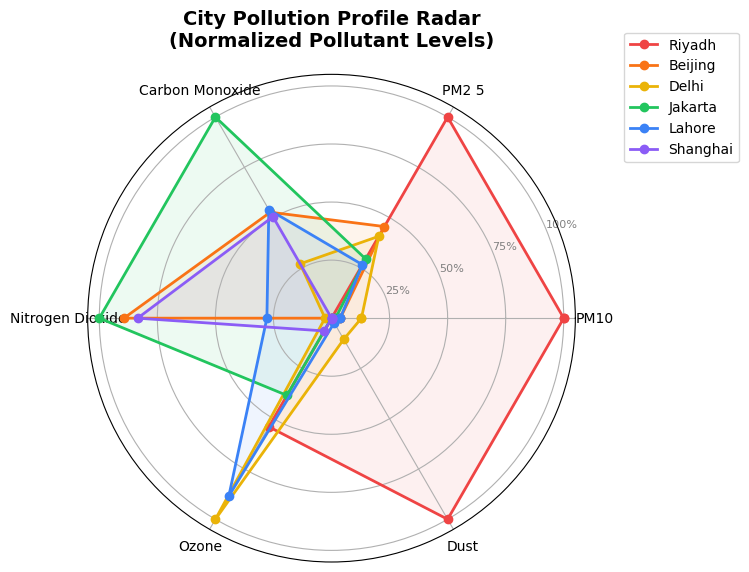

In [38]:

pollutants = ['PM10_ug_m3', 'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3',
              'Nitrogen_Dioxide_ug_m3', 'Ozone_ug_m3', 'Dust_ug_m3']

top_cities = df.groupby('City')[pollutants].mean()
top_cities = top_cities.nlargest(6, 'PM2_5_ug_m3')

# Normalize 0-1
top_cities_norm = (top_cities - top_cities.min()) / (top_cities.max() - top_cities.min())

N = len(pollutants)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = ['#EF4444','#F97316','#EAB308','#22C55E','#3B82F6','#8B5CF6']

for i, (city, row) in enumerate(top_cities_norm.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=city, color=colors[i])
    ax.fill(angles, values, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels([p.replace('_ug_m3','').replace('_',' ') for p in pollutants], fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%','50%','75%','100%'], fontsize=8, color='grey')
ax.set_title('City Pollution Profile Radar\n(Normalized Pollutant Levels)', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout(); plt.show()


### 2️⃣City × Pollutant Heatmap

C:\Users\malli\AppData\Local\Temp\ipykernel_17064\590401640.py:18: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
c:\Users\malli\anaconda3\envs\myenv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


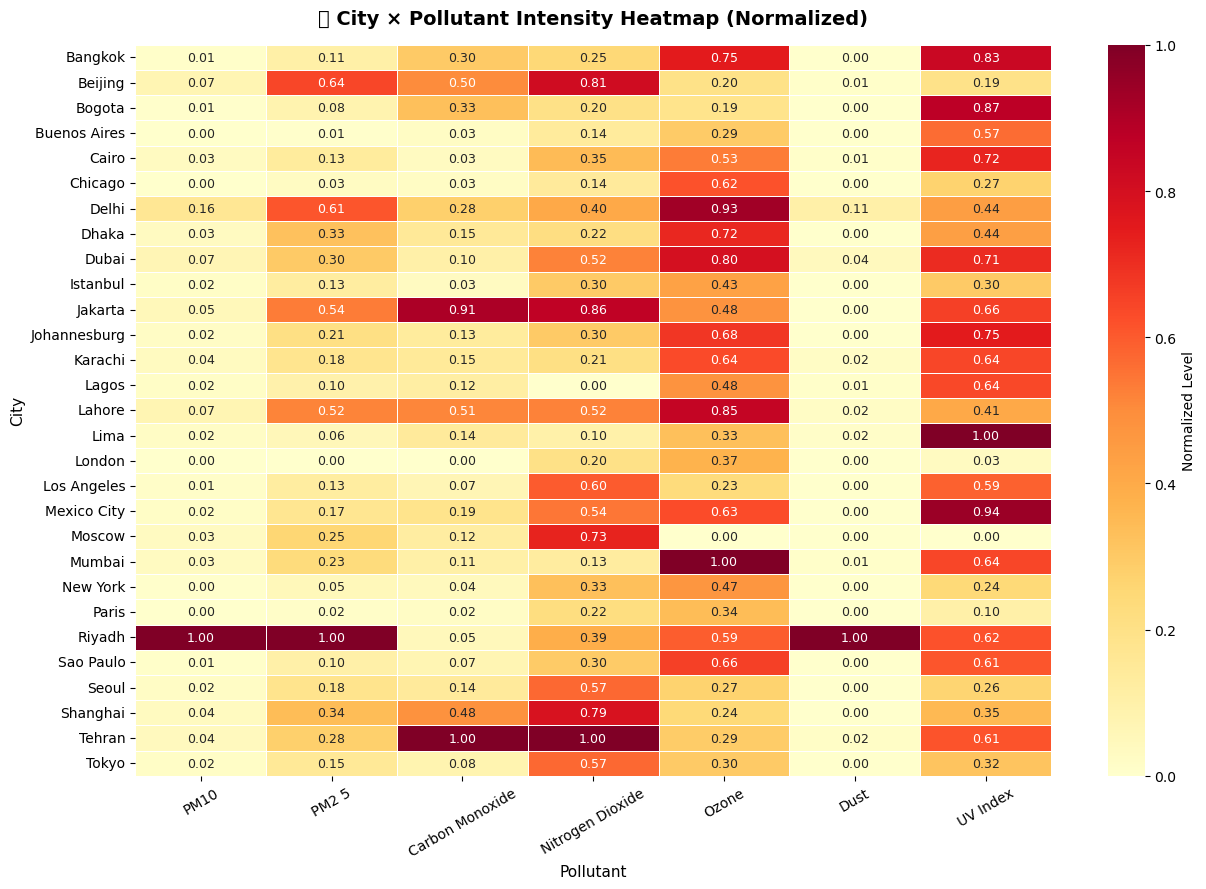

In [39]:
pollutants = ['PM10_ug_m3', 'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3',
              'Nitrogen_Dioxide_ug_m3', 'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index']

city_avg = df.groupby('City')[pollutants].mean()
city_avg_norm = (city_avg - city_avg.min()) / (city_avg.max() - city_avg.min())
city_avg_norm.columns = [c.replace('_ug_m3','').replace('_',' ') for c in city_avg_norm.columns]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(city_avg_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax, cbar_kws={'label': 'Normalized Level'})
ax.set_title('🌍 City × Pollutant Intensity Heatmap (Normalized)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Pollutant', fontsize=11)
ax.set_ylabel('City', fontsize=11)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout(); plt.show()


### FOR PREDICTING THE Hazardous_Event 

In [40]:
x=df.iloc[:,2:11]
x.columns

Index(['Latitude', 'Longitude', 'PM10_ug_m3', 'PM2_5_ug_m3',
       'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3', 'Ozone_ug_m3',
       'Dust_ug_m3', 'UV_Index'],
      dtype='str')

In [41]:
y=df.iloc[:,12]
y

0         0
1         0
2         0
3         0
4         0
         ..
254731    0
254732    0
254733    0
254734    0
254735    0
Name: Hazardous_Event, Length: 254710, dtype: int64

In [42]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=15,test_size=0.33)

In [43]:
rfc=RandomForestClassifier()

In [44]:
rfc.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_pred=rfc.predict(x_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [46]:
print("Predicted Score Is:",rfc.score(x_test,y_test)*100,"%")

Predicted Score Is: 95.80631729224912 %


### 3️⃣ RFC Feature Importance — Bubble Chart

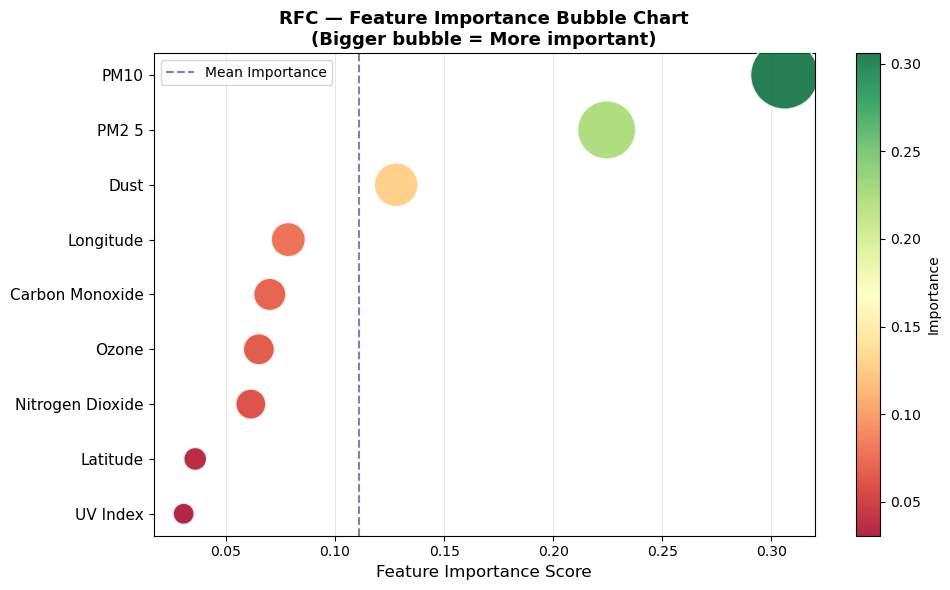

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

feature_names = x.columns.tolist()
importances = rfc.feature_importances_

# Sort
idx = np.argsort(importances)
names_sorted = [feature_names[i] for i in idx]
imp_sorted = importances[idx]

# Color by importance
colors_bubble = plt.cm.RdYlGn(imp_sorted / imp_sorted.max())
y_pos = np.arange(len(names_sorted))

scatter = ax.scatter(imp_sorted, y_pos, 
                     s=imp_sorted * 8000,
                     c=imp_sorted, cmap='RdYlGn',
                     alpha=0.85, edgecolors='white', linewidths=1.5, zorder=3)

ax.set_yticks(y_pos)
ax.set_yticklabels([n.replace('_ug_m3','').replace('_',' ') for n in names_sorted], fontsize=11)
ax.set_xlabel('Feature Importance Score', fontsize=12)
ax.set_title('RFC — Feature Importance Bubble Chart\n(Bigger bubble = More important)', 
             fontsize=13, fontweight='bold')
ax.axvline(np.mean(importances), color='navy', linestyle='--', alpha=0.5, label='Mean Importance')
ax.grid(axis='x', alpha=0.3)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Importance')
plt.tight_layout(); plt.show()


### FOR PREDICTING THE European_AQI 

In [48]:
df.columns

Index(['Timestamp', 'City', 'Latitude', 'Longitude', 'PM10_ug_m3',
       'PM2_5_ug_m3', 'Carbon_Monoxide_ug_m3', 'Nitrogen_Dioxide_ug_m3',
       'Ozone_ug_m3', 'Dust_ug_m3', 'UV_Index', 'European_AQI',
       'Hazardous_Event'],
      dtype='str')

In [49]:
x1=df.iloc[:,4:11]
x1

,PM10_ug_m3,PM2_5_ug_m3,Carbon_Monoxide_ug_m3,Nitrogen_Dioxide_ug_m3,Ozone_ug_m3,Dust_ug_m3,UV_Index
0,186.7,74.3,926.0,22.9,94.0,197.0,0.0
1,286.8,96.4,736.0,18.1,103.0,356.0,0.0
2,380.0,122.0,599.0,14.1,110.0,506.0,0.0
3,486.2,149.9,548.0,11.7,114.0,640.0,0.0
4,581.1,172.8,550.0,10.1,118.0,765.0,0.0
...,...,...,...,...,...,...,...
254731,19.0,15.3,215.0,36.1,15.0,0.0,0.0
254732,19.5,15.8,201.0,40.1,11.0,0.0,0.0
254733,19.7,15.9,181.0,41.6,9.0,0.0,0.0
254734,19.4,15.5,151.0,39.1,10.0,0.0,0.0


In [50]:
y1=df.iloc[:,11]
y1

0         76
1         77
2         78
3         80
4         85
          ..
254731    31
254732    30
254733    29
254734    29
254735    28
Name: European_AQI, Length: 254710, dtype: int64

In [51]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y1,random_state=15,test_size=0.33)

In [52]:
sc=MinMaxScaler(feature_range=(0,1))


In [53]:
x1_train=sc.fit_transform(x1_train)
x1_test=sc.transform(x1_test)

In [54]:
knn=KNeighborsRegressor(n_neighbors=15)

In [55]:
knn.fit(x1_train,y1_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [56]:
y_pred1=knn.predict(x1_test)
y_pred1

array([39.73333333, 36.8       , 22.8       , ..., 76.46666667,
       88.33333333, 17.4       ])

In [57]:
print("Predicted Score Is:",knn.score(x1_test,y1_test)*100,"%")

Predicted Score Is: 83.1805231068916 %


In [58]:
from sklearn.metrics import mean_squared_error, r2_score

In [59]:
print("R² Score :", round(r2_score(y1_test, y_pred1), 4))
print("RMSE     :", round(np.sqrt(mean_squared_error(y1_test, y_pred1)), 4))
print("Train R² :", round(knn.score(x1_train, y1_train), 4))

R² Score : 0.8318
RMSE     : 41.3053
Train R² : 0.8543


In [60]:
# Try different K values
for k in [3, 5, 7, 10, 15, 20]:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x1_train, y1_train)
    score = r2_score(y1_test, knn.predict(x1_test))
    print(f"K={k}  →  R²: {round(score, 4)}")

K=3  →  R²: 0.802
K=5  →  R²: 0.8184
K=7  →  R²: 0.8235
K=10  →  R²: 0.8284
K=15  →  R²: 0.8318
K=20  →  R²: 0.8321


### 4️⃣ K-Value Elbow Curve (Gradient Fill)

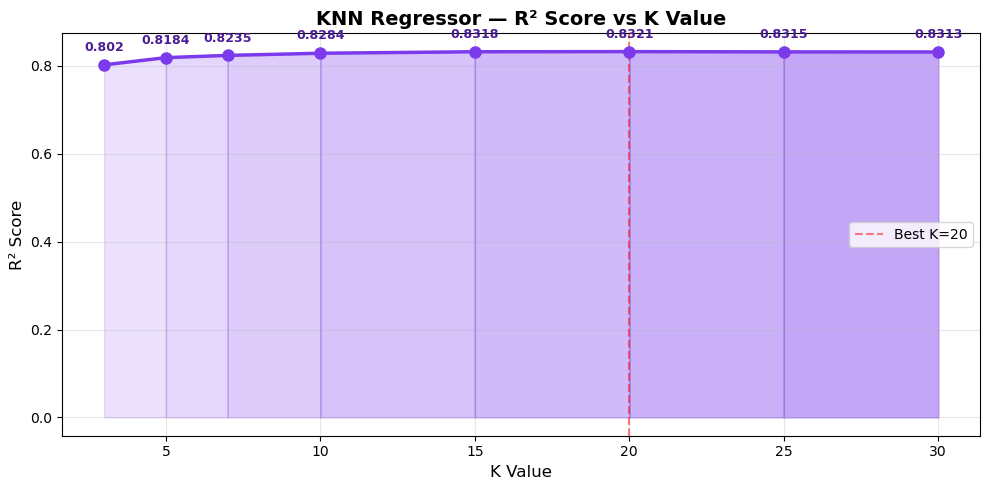

Best K: 20 | Best R²: 0.8321


In [61]:
k_values = [3, 5, 7, 10, 15, 20, 25, 30]
r2_scores = []
for k in k_values:
    m = KNeighborsRegressor(n_neighbors=k)
    m.fit(x1_train, y1_train)
    r2_scores.append(round(r2_score(y1_test, m.predict(x1_test)), 4))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, r2_scores, 'o-', color='#7C3AED', linewidth=2.5, markersize=8, zorder=3)

# Gradient fill under curve
for i in range(len(k_values)-1):
    ax.fill_between([k_values[i], k_values[i+1]], 
                    [r2_scores[i], r2_scores[i+1]], 
                    alpha=0.15 + i*0.05, color='#7C3AED')

for k, s in zip(k_values, r2_scores):
    ax.annotate(f'{s}', (k, s), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=9, color='#4C1D95', fontweight='bold')

best_k = k_values[r2_scores.index(max(r2_scores))]
ax.axvline(x=best_k, linestyle='--', color='red', alpha=0.5, label=f'Best K={best_k}')
ax.set_xlabel('K Value', fontsize=12)
ax.set_ylabel('R² Score', fontsize=12)
ax.set_title('KNN Regressor — R² Score vs K Value', fontsize=14, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Best K:", best_k, "| Best R²:", max(r2_scores))


###  5️⃣ Actual vs Predicted AQI + Residual Distribution

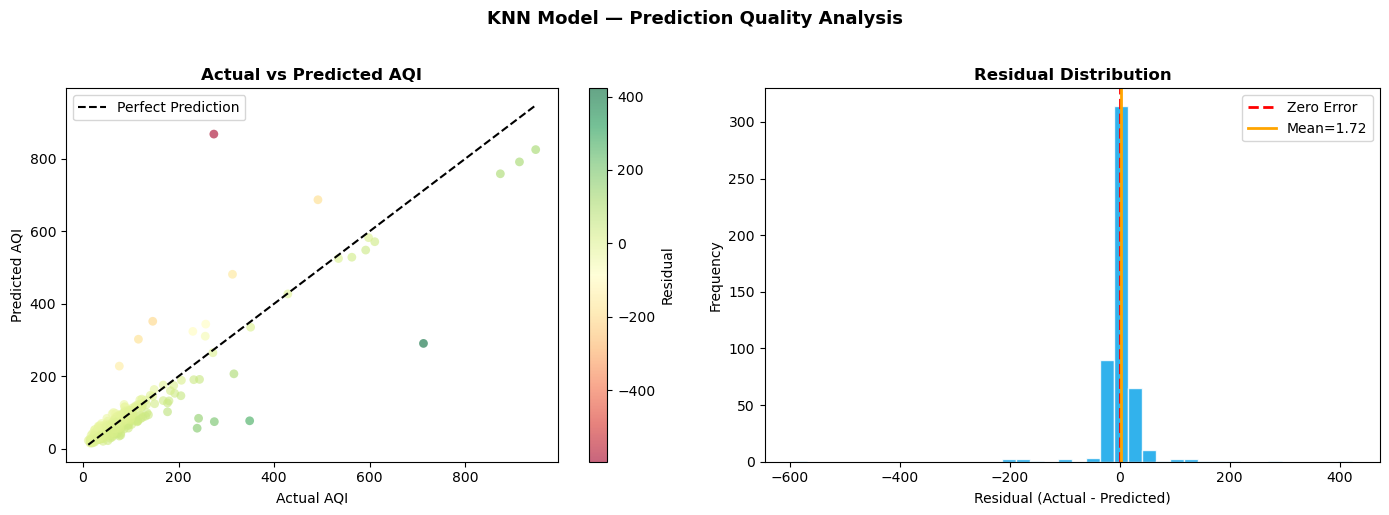

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample for clarity
sample = np.random.choice(len(y1_test), 500, replace=False)
y_actual = np.array(y1_test)[sample]
y_predicted = y_pred1[sample]
residuals = y_actual - y_predicted

# Left: Scatter actual vs predicted
sc = axes[0].scatter(y_actual, y_predicted, c=residuals, cmap='RdYlGn', 
                     alpha=0.6, edgecolors='none', s=40)
axes[0].plot([y_actual.min(), y_actual.max()], 
             [y_actual.min(), y_actual.max()], 
             'k--', linewidth=1.5, label='Perfect Prediction')
plt.colorbar(sc, ax=axes[0], label='Residual')
axes[0].set_xlabel('Actual AQI'); axes[0].set_ylabel('Predicted AQI')
axes[0].set_title('Actual vs Predicted AQI', fontweight='bold')
axes[0].legend()

# Right: Residual distribution
axes[1].hist(residuals, bins=40, color='#0EA5E9', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='-', linewidth=2, 
                label=f'Mean={residuals.mean():.2f}')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.suptitle('KNN Model — Prediction Quality Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
